# FER — Facial Emotion Recognition


**Input:** 6-channel stacked image (original + occluded face)  
**Models:** ResNet18 · ResNet50  · ViT  · Multi Scale ViT  

##Install & Mount

In [1]:
import sys
!{sys.executable} -m pip install numpy opencv-python timm mediapipe torch torchvision grad-cam


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import os
!pip install numpy 

TRAIN_DIR  = 'Autism emotion dataset/train'
TEST_DIR   = 'Autism emotion dataset/test'
MODELS_DIR = 'Autism emotion recognition dataset/models'
OUTPUT_DIR = 'Autism emotion recognition dataset/results'

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'TRAIN_DIR: {TRAIN_DIR}')
print(f'TEST_DIR: {TEST_DIR}')
print(f'MODELS_DIR: {MODELS_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/0a/0d/0e3ecece05b7a7e87ab9fb587855548da437a061326fff64a223b6dcb78a/numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: '/opt/jupyterhub/lib64/python3.12/site-packages/numpy'
Check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
TRAIN_DIR: Autism emotion dataset/train
TEST_DIR: Autism emotion dataset/test
MODELS_DIR: Autism emotion recognition dataset/models
OUTPUT_DIR: Autism emotion recognition dataset/results


##Imports

In [3]:
import os
import json
import shutil
import random
import urllib.request
from pathlib import Path

import numpy as np
import cv2
import timm
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torchvision import transforms, models
from torchvision.models import efficientnet_b0
from torch.utils.data import Dataset, DataLoader, random_split

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import face_landmarker
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode

from sklearn.metrics import  confusion_matrix, recall_score, precision_score,f1_score, roc_curve, auc, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import label_binarize
from torch.utils.data import WeightedRandomSampler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

/home/compute.ashesi.lan/babraham/python-env/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


##Constants

In [4]:
EMOTIONS    = ['anger', 'fear', 'joy', 'Natural', 'sadness', 'surprise']

CLASS_MAP = {}
for i, e in enumerate(EMOTIONS):
    CLASS_MAP[e] = i

IDX_CLASS = {}
for e, i in CLASS_MAP.items():
    IDX_CLASS[i] = e


NUM_CLASSES = len(EMOTIONS)

NUM_EPOCHS  = 50
BATCH_SIZE  = 32
PATIENCE    = 5

print(f'Classes : {EMOTIONS}')
print(f'Epochs  : {NUM_EPOCHS}  |  Patience: {PATIENCE}')

Classes : ['anger', 'fear', 'joy', 'Natural', 'sadness', 'surprise']
Epochs  : 50  |  Patience: 5


## Download MediaPipe Model

In [5]:
MP_MODEL_PATH = 'face_landmarker.task'
if not os.path.exists(MP_MODEL_PATH):
    print('Downloading face_landmarker.task...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
        MP_MODEL_PATH
    )
    print('Done')
else:
    print('Already present.')

Already present.


## Occlusion Class

In [6]:
class FacialRegionOcclusion:

    REGION_INDICES = {
        'left_eye':  [33, 160, 158, 133, 153, 144],
        'right_eye': [362, 385, 387, 263, 373, 380],
        'nose':      [1, 2, 98, 327, 168, 195],
    }

    def __init__(self, regions=['left_eye', 'right_eye', 'nose'],occlusion_value=0, model_path=MP_MODEL_PATH):

        self.regions  = regions
        self.occlusion_value = occlusion_value
        self.region_indices  = self.REGION_INDICES

        base_options = python.BaseOptions(model_asset_path=model_path)
        options = face_landmarker.FaceLandmarkerOptions(
            base_options=base_options,
            running_mode=VisionTaskRunningMode.IMAGE
        )
        self.landmarker = face_landmarker.FaceLandmarker.create_from_options(options)

    def get_landmarks(self, image_np):
        if image_np.dtype != np.uint8:
            image_np = image_np.astype(np.uint8)

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_np)
        results  = self.landmarker.detect(mp_image)
        if not results.face_landmarks:
            return None
        lms = results.face_landmarks[0]
        return [(int(lm.x * image_np.shape[1]), int(lm.y * image_np.shape[0])) for lm in lms]

    def occlude_region(self, image_np, landmarks, region_name):
        indices  = self.region_indices[region_name]
        points   = np.array([landmarks[i] for i in indices], dtype=np.int32)
        center_x = int(np.mean([p[0] for p in points]))
        center_y = int(np.mean([p[1] for p in points]))
        h, w     = image_np.shape[:2]
        box_size = 0.25
        box_h, box_w = int(h * box_size), int(w * box_size)
        top    = max(0, center_y - box_h // 2)
        bottom = min(h, top + box_h)
        left   = max(0, center_x - box_w // 2)
        right  = min(w, left + box_w)
        image_np[top:bottom, left:right] = int(self.occlusion_value * 255)
        return image_np

    def __call__(self, pil_image):
        image_np  = np.array(pil_image)
        landmarks = self.get_landmarks(image_np)
        if landmarks is None:
            return pil_image
        occluded = image_np.copy()
        for region in self.regions:
            occluded = self.occlude_region(occluded, landmarks, region)
        return Image.fromarray(occluded)


class EmotionOcclusionDataset(Dataset):
    def __init__(self, root_dir, occlusion_regions, preprocess=None):
        self.preprocess        = preprocess
        self.occlusion_regions = occlusion_regions
        self.samples           = []
        self.occluders = {
            region: FacialRegionOcclusion(regions=(region,))
            for region in occlusion_regions
        }
        root_dir = Path(root_dir)
        for class_name, label in CLASS_MAP.items():
            class_dir = root_dir / class_name
            if not class_dir.exists():
                print(f'Warning: {class_dir} not found, skipping.')
                continue
            for img_path in class_dir.glob('*.jpg'):
                self.samples.append((img_path, label))
        print(f'Total samples: {len(self.samples)}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        pil_image = Image.open(img_path).convert('RGB')
        original  = self.preprocess(pil_image)
        region    = region = self.occlusion_regions[idx % len(self.occlusion_regions)]
        occ_pil   = self.occluders[region](pil_image)
        occluded  = self.preprocess(occ_pil)
        stacked   = torch.cat([original, occluded], dim=0)   # (6, 224, 224)
        return stacked, label

print('Dataset classes defined.')

Dataset classes defined.


##DataLoaders

In [ ]:


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

occlusion_regions = ['left_eye', 'right_eye', 'nose']

full_train = EmotionOcclusionDataset(TRAIN_DIR, occlusion_regions, preprocess=train_transform)
test_data  = EmotionOcclusionDataset(TEST_DIR,  occlusion_regions, preprocess=val_transform)

train_size = int(0.8 * len(full_train))
val_size   = len(full_train) - train_size
generator  = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train, [train_size, val_size], generator=generator)

# ── Class Imbalance Fix with WeightedRandomSampler 

train_indices  = train_dataset.indices
train_labels   = [full_train.samples[i][1] for i in train_indices]

class_counts   = np.bincount(train_labels)
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[l] for l in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_data,     batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(train_dataset)}')
print(f'Val   : {len(val_dataset)}')
print(f'Test  : {len(test_data)}')
print(f'Class counts : {class_counts}')
print(f'Class weights: {class_weights.round(4)}')

W0000 00:00:1775482517.831582  521495 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1775482517.873116  521495 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775482517.960339  521668 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 590.44.01), renderer: Quadro RTX 6000/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775482517.976845  521515 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775482517.991130  521540 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775482517.995480  521939 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1775482518.001165  521939 gl_context_egl.cc:85] Successf

Total samples: 1194
Total samples: 226
Train : 955
Val   : 239
Test  : 226
Class counts : [160 156 156 164 160 159]
Class weights: [0.0062 0.0064 0.0064 0.0061 0.0062 0.0063]


I0000 00:00:1775482518.269946  522620 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 590.44.01), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1775482518.273248  522587 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775482518.287364  522603 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775482518.291858  522812 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1775482518.297893  522812 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775482518.334986  522854 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 590.44.01), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1775482518.338280  522818 inference_feedback_manager.cc:114] Feedback manager requires a model with

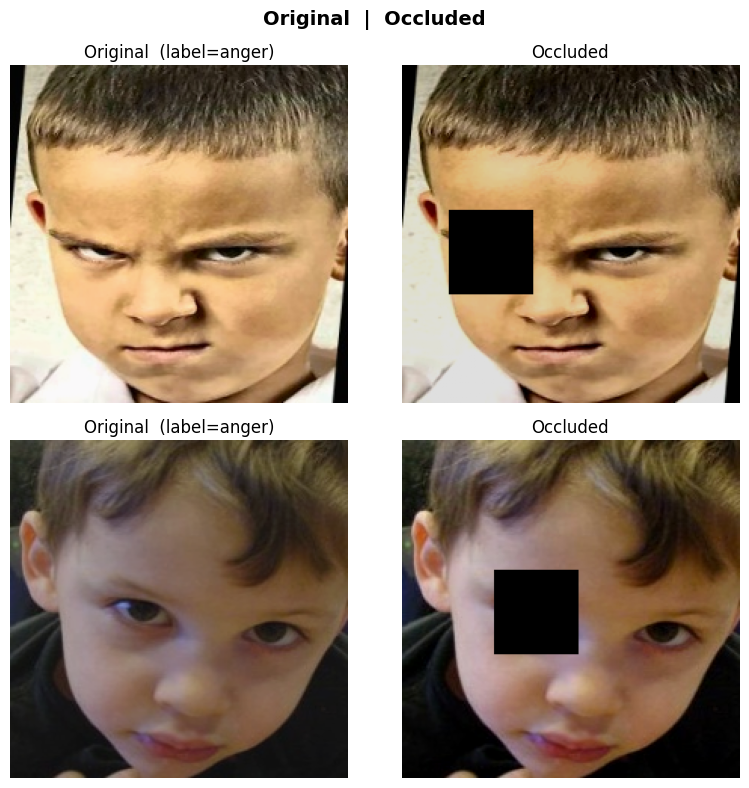

In [8]:
def display_examples(dataset, n=2):
    fig, axes = plt.subplots(n, 2, figsize=(8, 4*n), squeeze=False)
    fig.suptitle('Original  |  Occluded', fontsize=14, fontweight='bold')

    def to_display(t):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        return (t * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()

    for i in range(n):
        stacked, label = dataset[i]
        axes[i, 0].imshow(to_display(stacked[:3]))
        axes[i, 0].set_title(f'Original  (label={IDX_CLASS[label]})')
        axes[i, 0].axis('off')
        axes[i, 1].imshow(to_display(stacked[3:]))
        axes[i, 1].set_title('Occluded')
        axes[i, 1].axis('off')

    plt.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True) # Ensure output directory exists
    plt.savefig(os.path.join(OUTPUT_DIR, '6channel.png'), dpi=150)
    plt.show()

display_examples(full_train, n=2)

In [9]:
def build_resnet18():
    m = models.resnet18(weights='IMAGENET1K_V1')
    old_w  = m.conv1.weight.data
    new_w  = torch.cat([old_w, old_w], dim=1)
    m.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.conv1.weight = nn.Parameter(new_w)
    m.fc    = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m.to(DEVICE)

def build_resnet50():
    m = models.resnet50(weights='IMAGENET1K_V1')
    old_w  = m.conv1.weight.data
    new_w  = torch.cat([old_w, old_w], dim=1)   # (64, 6, 7, 7)
    m.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.conv1.weight = nn.Parameter(new_w)
    m.fc    = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m.to(DEVICE)

def build_vit():
    m = timm.create_model('vit_base_patch32_224', pretrained=True, num_classes=NUM_CLASSES, in_chans=6)
    return m.to(DEVICE)


class MultiScaleViT(nn.Module):

    def __init__(self, num_classes=6, in_chans=6, pretrained=True):
        super().__init__()


        self.backbone = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            num_classes=0,          # remove head — we want raw CLS token
            in_chans=in_chans,
            img_size=224
        )
        embed_dim = self.backbone.embed_dim   # 768 for vit_base

        # Downsample layers to create 112 and 56 scale inputs
        self.down2 = nn.AdaptiveAvgPool2d((112, 112))
        self.down4 = nn.AdaptiveAvgPool2d((56, 56))


        self.up_from_112 = nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False)
        self.up_from_56  = nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False)

        # Fusion MLP: 3 CLS tokens → num_classes
        self.fusion = nn.Sequential(
            nn.LayerNorm(embed_dim * 3),
            nn.Linear(embed_dim * 3, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward_one_scale(self, x):
        """Get CLS token from backbone for one scale."""
        return self.backbone(x)   # (B, embed_dim)

    def forward(self, x):
        # Scale 1 — full resolution 224
        feat_224 = self.forward_one_scale(x)

        # Scale 2 — half resolution: downsample to 112, upsample to 224
        x_112    = self.up_from_112(self.down2(x))
        feat_112 = self.forward_one_scale(x_112)

        # Scale 3 — quarter resolution: downsample to 56, upsample to 224
        x_56     = self.up_from_56(self.down4(x))
        feat_56  = self.forward_one_scale(x_56)

        # Concatenate all three CLS tokens → fuse
        fused = torch.cat([feat_224, feat_112, feat_56], dim=1)   # (B, 768*3)
        return self.fusion(fused)


def build_multiscale_vit():
    m = MultiScaleViT(num_classes=NUM_CLASSES, in_chans=6, pretrained=True)
    return m.to(DEVICE)

print('Model builders ready — including MultiScaleViT.')

Model builders ready — including MultiScaleViT.


In [10]:
def train_model(model, model_name, lr, save_path, patience=PATIENCE):
    """
    Train with early stopping. Saves the best val-accuracy checkpoint.
    Returns (trained_model, best_val_acc, history).
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_val_acc      = 0.0
    epochs_no_improve = 0
    history           = []

    print(f'\n{"="*60}')
    print(f'  Training: {model_name}  |  LR: {lr}')
    print(f'{"="*60}')
    print(f'{"Epoch":<8}{"Train Loss":<14}{"Train Acc":<14}{"Val Loss":<14}{"Val Acc"}')
    print('-'*58)

    for epoch in range(1, NUM_EPOCHS + 1):
        # ── Train ────────────────────────────────────────────
        model.train()
        tr_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(images)                                    # single forward pass
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * images.size(0)
            correct += out.detach().argmax(1).eq(labels).sum().item()
            total   += labels.size(0)

        tr_loss /= total                                            # normalise
        tr_acc   = correct / total

        # ── Validate ─────────────────────────────────────────
        model.eval()
        vl_loss, correct_v, total_v = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                out    = model(images)
                loss   = criterion(out, labels)
                vl_loss   += loss.item() * images.size(0)
                correct_v += out.argmax(1).eq(labels).sum().item()
                total_v   += labels.size(0)
        vl_loss /= total_v
        vl_acc   = correct_v / total_v

        scheduler.step(vl_loss)
        history.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_acc': tr_acc,
                        'vl_loss': vl_loss, 'vl_acc': vl_acc})

        print(f'{epoch:<8}{tr_loss:<14.4f}{tr_acc:<14.4f}{vl_loss:<14.4f}{vl_acc:.4f}', end='')

        # ── Early stopping ───────────────────────────────────
        if vl_acc > best_val_acc:
            best_val_acc      = vl_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print('  saved')
        else:
            epochs_no_improve += 1
            print()
            if epochs_no_improve >= patience:
                print(f'\n⚠ Early stopping at epoch {epoch} (no improvement for {patience} epochs)')
                break

    print(f'\nBest val acc: {best_val_acc:.4f}')
    # Load best weights back
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    return model, best_val_acc, history

In [11]:
def evaluate_model(model, loader, model_name='model'):
    """Full evaluation: accuracy, F1, ROC, confusion matrix."""
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            out        = model(images)
            probs      = torch.softmax(out, dim=1)
            total_loss += criterion(out, labels).item() * images.size(0)  # weighted sum
            preds      = out.argmax(1)
            correct    += preds.eq(labels).sum().item()
            total      += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    total_loss /= total                                                    # normalise
    acc        = correct / total
    precision  = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall     = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1         = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    cm         = confusion_matrix(all_labels, all_preds)

    print(f'\n── {model_name} ─────────────────────────────')
    print(f'  Loss      : {total_loss:.4f}')                              # now printed
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(classification_report(all_labels, all_preds, target_names=EMOTIONS, zero_division=0))

    # Plots
    y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(model_name, fontsize=13, fontweight='bold')

    for c in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, c], all_probs[:, c])
        axes[0].plot(fpr, tpr, lw=2, label=f'{EMOTIONS[c]} (AUC={auc(fpr, tpr):.2f})')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set(title='ROC Curves', xlabel='FPR', ylabel='TPR')
    axes[0].legend(fontsize=8)

    ConfusionMatrixDisplay(cm, display_labels=EMOTIONS).plot(ax=axes[1], colorbar=True, xticks_rotation=45)
    axes[1].set_title('Confusion Matrix')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{model_name}_evaluation.png'), dpi=150)
    plt.show()

    return acc, f1, all_probs

print('evaluate_model function defined.')

evaluate_model function defined.


##Training Curve PLot

In [12]:
def plot_history(history, model_name):
    epochs   = [h['epoch']   for h in history]
    tr_acc   = [h['tr_acc']  for h in history]
    vl_acc   = [h['vl_acc']  for h in history]
    tr_loss  = [h['tr_loss'] for h in history]
    vl_loss  = [h['vl_loss'] for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, tr_acc,  label='Train', color='#4472C4')
    axes[0].plot(epochs, vl_acc,  label='Val',   color='#ED7D31')
    axes[0].set(title='Accuracy', xlabel='Epoch', ylabel='Acc')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, tr_loss, label='Train', color='#4472C4')
    axes[1].plot(epochs, vl_loss, label='Val',   color='#ED7D31')
    axes[1].set(title='Loss', xlabel='Epoch', ylabel='Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(f'{model_name} — Training Curves', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{model_name}_curves.png'), dpi=150)
    plt.show()

print('plot_history defined.')

plot_history defined.


In [13]:
results   = {}
histories = {}


  Training: resnet18  |  LR: 0.001
Epoch   Train Loss    Train Acc     Val Loss      Val Acc
----------------------------------------------------------
1       1.5186        0.4461        3.4136        0.2971  saved
2       1.1047        0.6199        1.4402        0.5188  saved
3       0.9017        0.7466        1.5321        0.4435
4       0.7514        0.7990        1.4949        0.4937
5       0.6210        0.8785        1.3292        0.6025  saved
6       0.6411        0.8513        1.4917        0.6276  saved
7       0.5509        0.8921        1.5316        0.5774
8       0.4562        0.9319        1.5570        0.5941
9       0.4383        0.9445        1.2057        0.6862  saved
10      0.4381        0.9393        1.2719        0.6402
11      0.3949        0.9613        1.1785        0.7029  saved
12      0.3793        0.9613        1.1331        0.7113  saved
13      0.3643        0.9644        1.1915        0.7155  saved
14      0.3685        0.9696        1.1584        

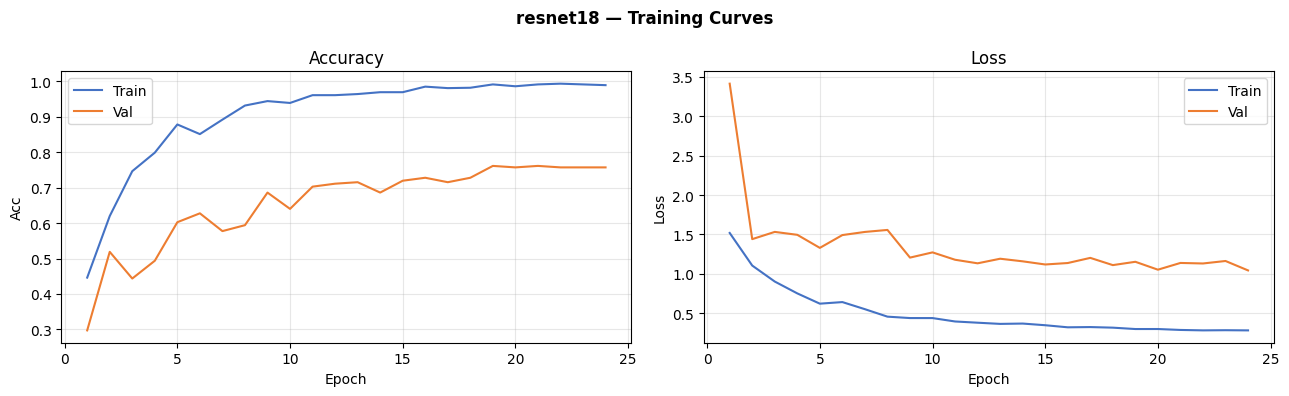


── resnet18 ─────────────────────────────
  Loss      : 1.3727
  Accuracy  : 0.6239
  Precision : 0.6141
  Recall    : 0.6259
  F1-Score  : 0.6125
              precision    recall  f1-score   support

       anger       0.51      0.70      0.59        40
        fear       0.72      0.81      0.76        36
         joy       0.91      0.83      0.87        35
     Natural       0.64      0.75      0.69        40
     sadness       0.27      0.16      0.20        38
    surprise       0.63      0.51      0.57        37

    accuracy                           0.62       226
   macro avg       0.61      0.63      0.61       226
weighted avg       0.61      0.62      0.61       226



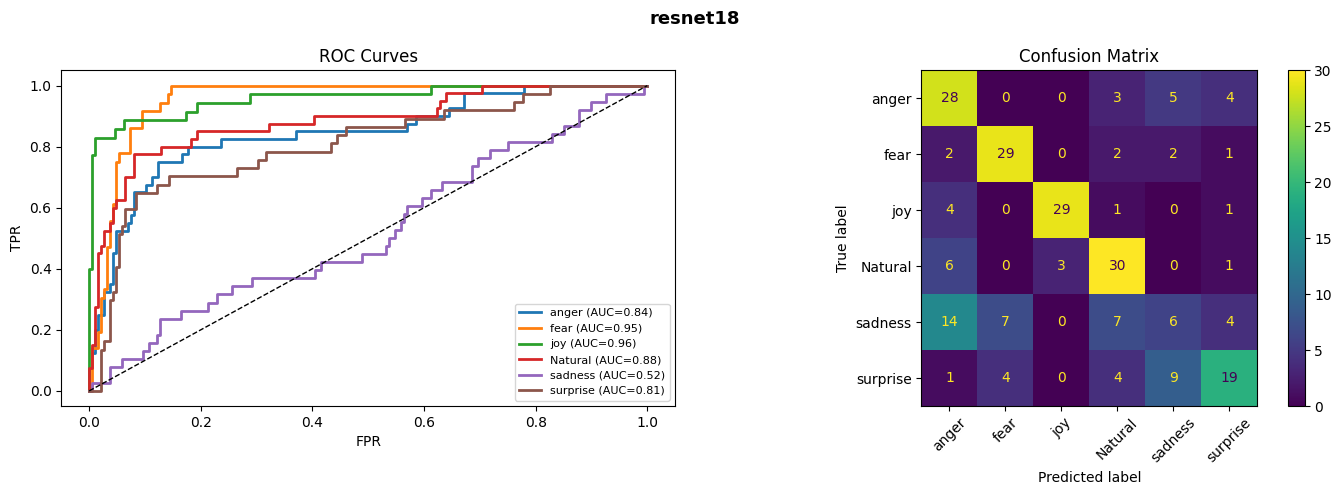

In [14]:
model_resnet18, best_acc, hist = train_model(
    build_resnet18(), 'resnet18', lr=1e-3,
    save_path=os.path.join(MODELS_DIR, 'resnet18_best.pth')
)
plot_history(hist, 'resnet18')
acc, f1, _ = evaluate_model(model_resnet18, test_loader, 'resnet18')
results['resnet18']   = acc
histories['resnet18'] = hist


  Training: resnet50  |  LR: 0.0005
Epoch   Train Loss    Train Acc     Val Loss      Val Acc
----------------------------------------------------------
1       1.4514        0.4911        5.6345        0.2092  saved
2       1.0481        0.6733        1.5377        0.4854  saved
3       0.8282        0.7675        1.2531        0.5983  saved
4       0.7752        0.7885        1.5556        0.5774
5       0.7237        0.8178        1.3583        0.6025  saved
6       0.6128        0.8743        1.2953        0.6444  saved
7       0.5247        0.8995        1.0903        0.7197  saved
8       0.4719        0.9288        1.0186        0.7238  saved
9       0.4418        0.9466        1.1114        0.7197
10      0.4072        0.9508        1.1292        0.7238
11      0.4080        0.9581        1.1056        0.6946
12      0.3977        0.9518        1.0958        0.7364  saved
13      0.3956        0.9571        1.3151        0.6402
14      0.3705        0.9634        1.2288       

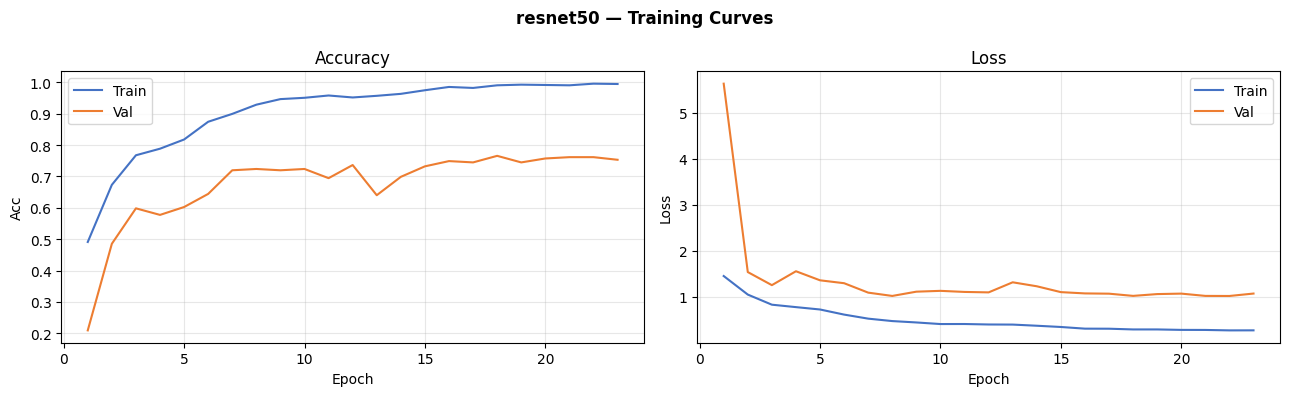


── resnet50 ─────────────────────────────
  Loss      : 1.2326
  Accuracy  : 0.6062
  Precision : 0.5949
  Recall    : 0.6108
  F1-Score  : 0.5974
              precision    recall  f1-score   support

       anger       0.50      0.68      0.57        40
        fear       0.77      0.92      0.84        36
         joy       0.91      0.83      0.87        35
     Natural       0.63      0.60      0.62        40
     sadness       0.25      0.16      0.19        38
    surprise       0.51      0.49      0.50        37

    accuracy                           0.61       226
   macro avg       0.59      0.61      0.60       226
weighted avg       0.59      0.61      0.59       226



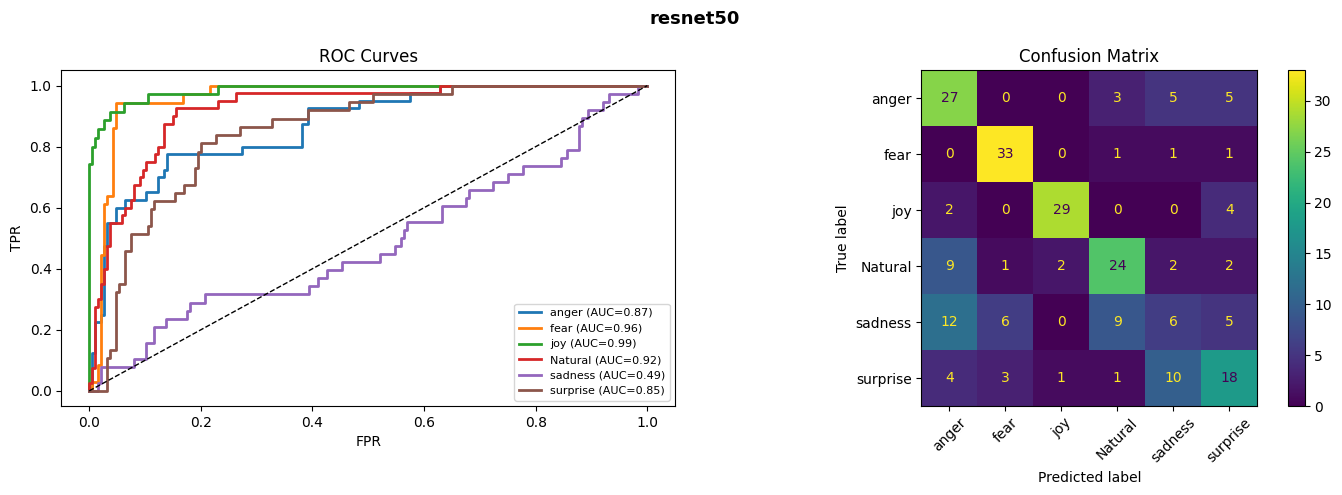

In [15]:
model_resnet50, best_acc, hist = train_model(
    build_resnet50(), 'resnet50', lr = 5e-4,
    save_path=os.path.join(MODELS_DIR, 'resnet50_best.pth')
)
plot_history(hist, 'resnet50')
acc, f1, _ = evaluate_model(model_resnet50, test_loader, 'resnet50')
results['resnet50']   = acc
histories['resnet50'] = hist


  Training: vit  |  LR: 5e-05
Epoch   Train Loss    Train Acc     Val Loss      Val Acc
----------------------------------------------------------
1       1.5388        0.4325        1.4222        0.4603  saved
2       0.9538        0.7267        1.2404        0.6067  saved
3       0.6363        0.8492        1.0483        0.6904  saved
4       0.4877        0.9204        0.9930        0.7364  saved
5       0.4241        0.9382        0.9617        0.7364
6       0.3585        0.9665        0.9724        0.7364
7       0.3436        0.9717        0.9085        0.7531  saved
8       0.3377        0.9759        1.0041        0.7615  saved
9       0.3259        0.9822        0.9240        0.7699  saved
10      0.2954        0.9885        0.9597        0.7699
11      0.3094        0.9843        0.9802        0.7322
12      0.2822        0.9948        0.9858        0.7573
13      0.2858        0.9916        0.9522        0.7573
14      0.2801        0.9916        0.9329        0.7531

⚠ Ea

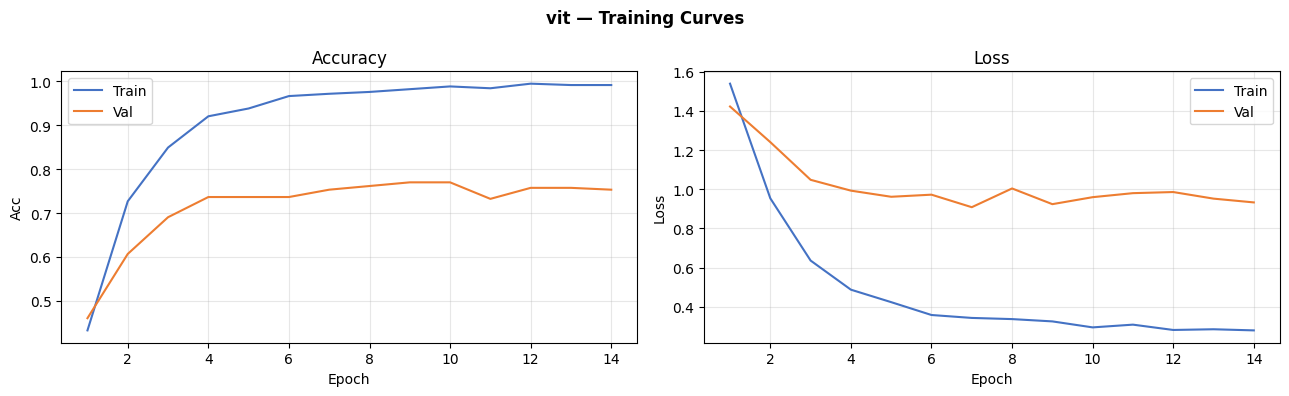


── vit ─────────────────────────────
  Loss      : 1.5419
  Accuracy  : 0.4912
  Precision : 0.5171
  Recall    : 0.4931
  F1-Score  : 0.5014
              precision    recall  f1-score   support

       anger       0.54      0.53      0.53        40
        fear       0.74      0.72      0.73        36
         joy       0.81      0.60      0.69        35
     Natural       0.56      0.57      0.57        40
     sadness       0.17      0.16      0.16        38
    surprise       0.29      0.38      0.33        37

    accuracy                           0.49       226
   macro avg       0.52      0.49      0.50       226
weighted avg       0.51      0.49      0.50       226



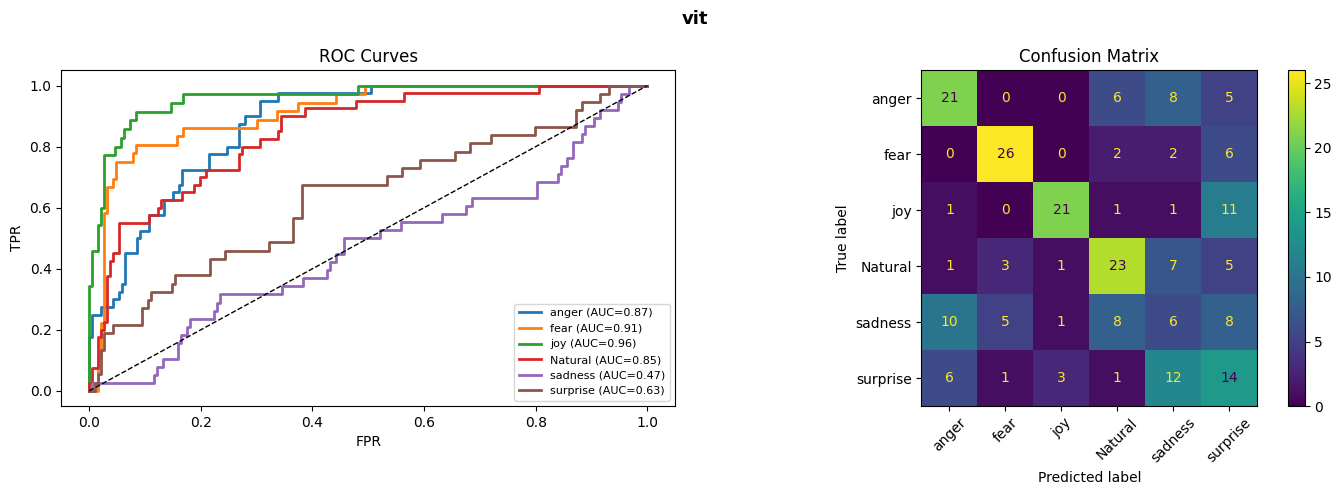

In [16]:
model_vit, best_acc, hist = train_model(
    build_vit(), 'vit', lr=5e-5,
    save_path=os.path.join(MODELS_DIR, 'vit_best.pth')
)
plot_history(hist, 'vit')
acc, f1, _ = evaluate_model(model_vit, test_loader, 'vit')
results['vit']   = acc
histories['vit'] = hist


  Training: multiscale_vit  |  LR: 2e-05
Epoch   Train Loss    Train Acc     Val Loss      Val Acc
----------------------------------------------------------
1       1.6271        0.3686        1.5483        0.4184  saved
2       1.1894        0.6545        1.1620        0.6025  saved
3       0.8179        0.7969        1.1019        0.6611  saved
4       0.5828        0.8838        1.0217        0.7071  saved
5       0.4834        0.9099        0.9278        0.7406  saved
6       0.4070        0.9466        0.9267        0.7448  saved
7       0.3579        0.9665        0.9511        0.7615  saved
8       0.3493        0.9592        0.9534        0.7699  saved
9       0.3353        0.9644        0.9767        0.7364
10      0.3060        0.9759        1.0547        0.7238
11      0.3024        0.9812        0.9686        0.7448
12      0.2981        0.9822        1.0071        0.7280
13      0.2846        0.9885        0.9649        0.7490

⚠ Early stopping at epoch 13 (no improvemen

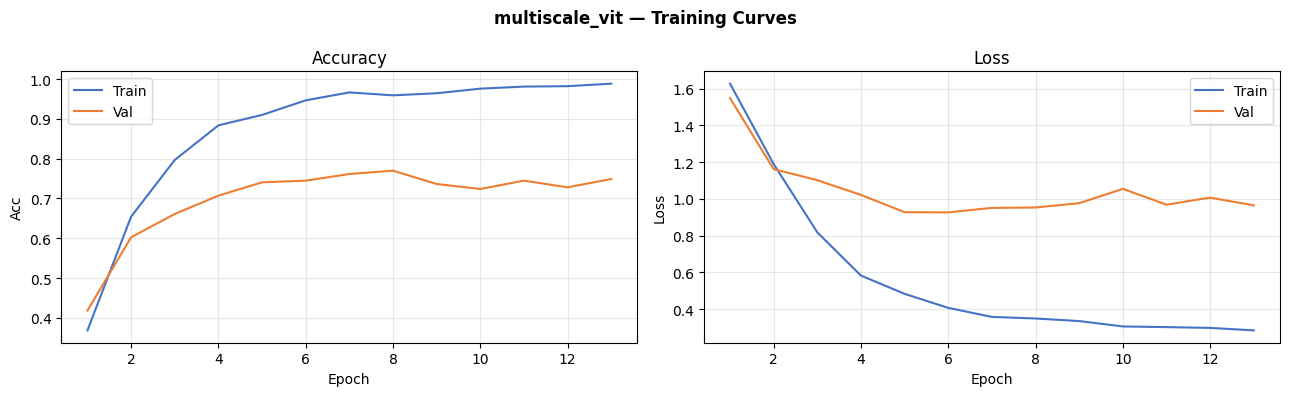


── multiscale_vit ─────────────────────────────
  Loss      : 1.4318
  Accuracy  : 0.5398
  Precision : 0.5427
  Recall    : 0.5427
  F1-Score  : 0.5273
              precision    recall  f1-score   support

       anger       0.46      0.82      0.59        40
        fear       0.76      0.53      0.62        36
         joy       0.88      0.83      0.85        35
     Natural       0.44      0.38      0.41        40
     sadness       0.20      0.11      0.14        38
    surprise       0.51      0.59      0.55        37

    accuracy                           0.54       226
   macro avg       0.54      0.54      0.53       226
weighted avg       0.53      0.54      0.52       226



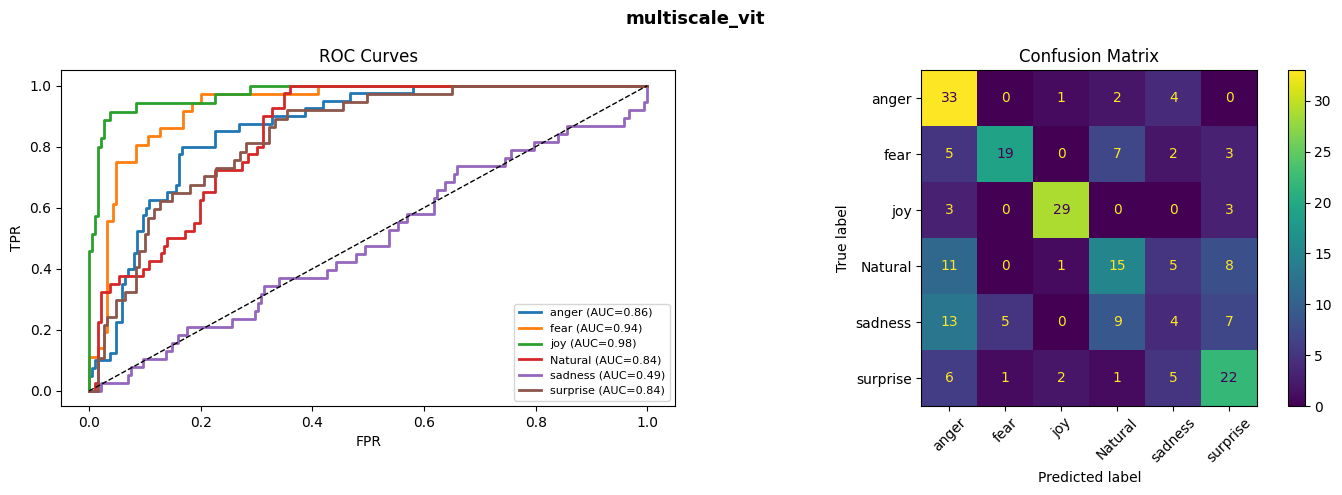

In [17]:
model_ms_vit, best_acc, hist = train_model(
    build_multiscale_vit(), 'multiscale_vit', lr=2e-5,
    save_path=os.path.join(MODELS_DIR, 'multiscale_vit_best.pth')
)
plot_history(hist, 'multiscale_vit')
acc, f1, _ = evaluate_model(model_ms_vit, test_loader, 'multiscale_vit')
results['multiscale_vit']   = acc
histories['multiscale_vit'] = hist


FER MODEL COMPARISON
Current results dictionary: {'resnet18': 0.6238938053097345, 'resnet50': 0.6061946902654868, 'vit': 0.4911504424778761, 'multiscale_vit': 0.5398230088495575}
Model              Test Acc
------------------------------
  resnet18        0.6239  BEST
  resnet50        0.6062
  multiscale_vit  0.5398
  vit             0.4912

 Best FER model: resnet18  (0.6239)


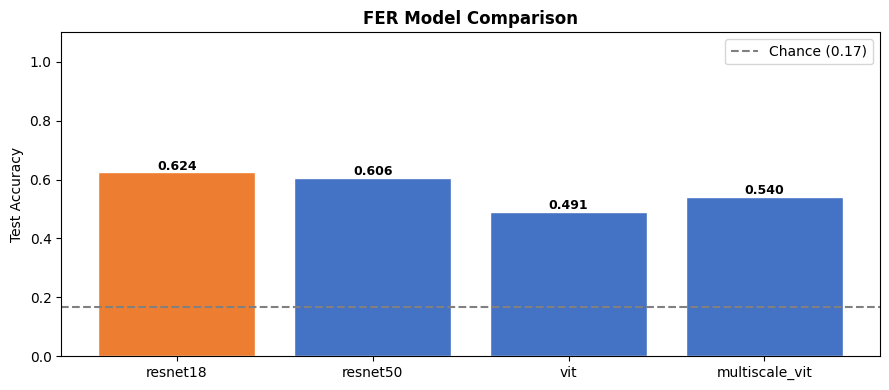

In [18]:
print('\n' + '='*45)
print('FER MODEL COMPARISON')
print('='*45)
print(f"Current results dictionary: {results}")

if not results:
    print('Warning: Results dictionary is empty. Ensure all model training cells have been executed successfully.')


else:
    print(f'{ "Model":<16}  {"Test Acc":>9}')
    print('-'*30)
    for name, acc in sorted(results.items(), key=lambda x: -x[1]):
        marker = '  BEST' if acc == max(results.values()) else ''
        print(f'  {name:<14}  {acc:.4f}{marker}')

    best_fer_model_name = max(results, key=results.get)
    print(f'\n Best FER model: {best_fer_model_name}  ({results[best_fer_model_name]:.4f})')

    # Bar chart
    names   = list(results.keys())
    accs    = [results[n] for n in names]
    colours = ['#ED7D31' if n == best_fer_model_name else '#4472C4' for n in names]
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(names, accs, color=colours, edgecolor='white')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Test Accuracy')
    ax.set_title('FER Model Comparison', fontweight='bold')
    ax.axhline(1/NUM_CLASSES, color='grey', linestyle='--', label=f'Chance ({1/NUM_CLASSES:.2f})')
    ax.legend()
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                f'{acc:.3f}', ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fer_model_comparison.png'), dpi=150)
    plt.show()

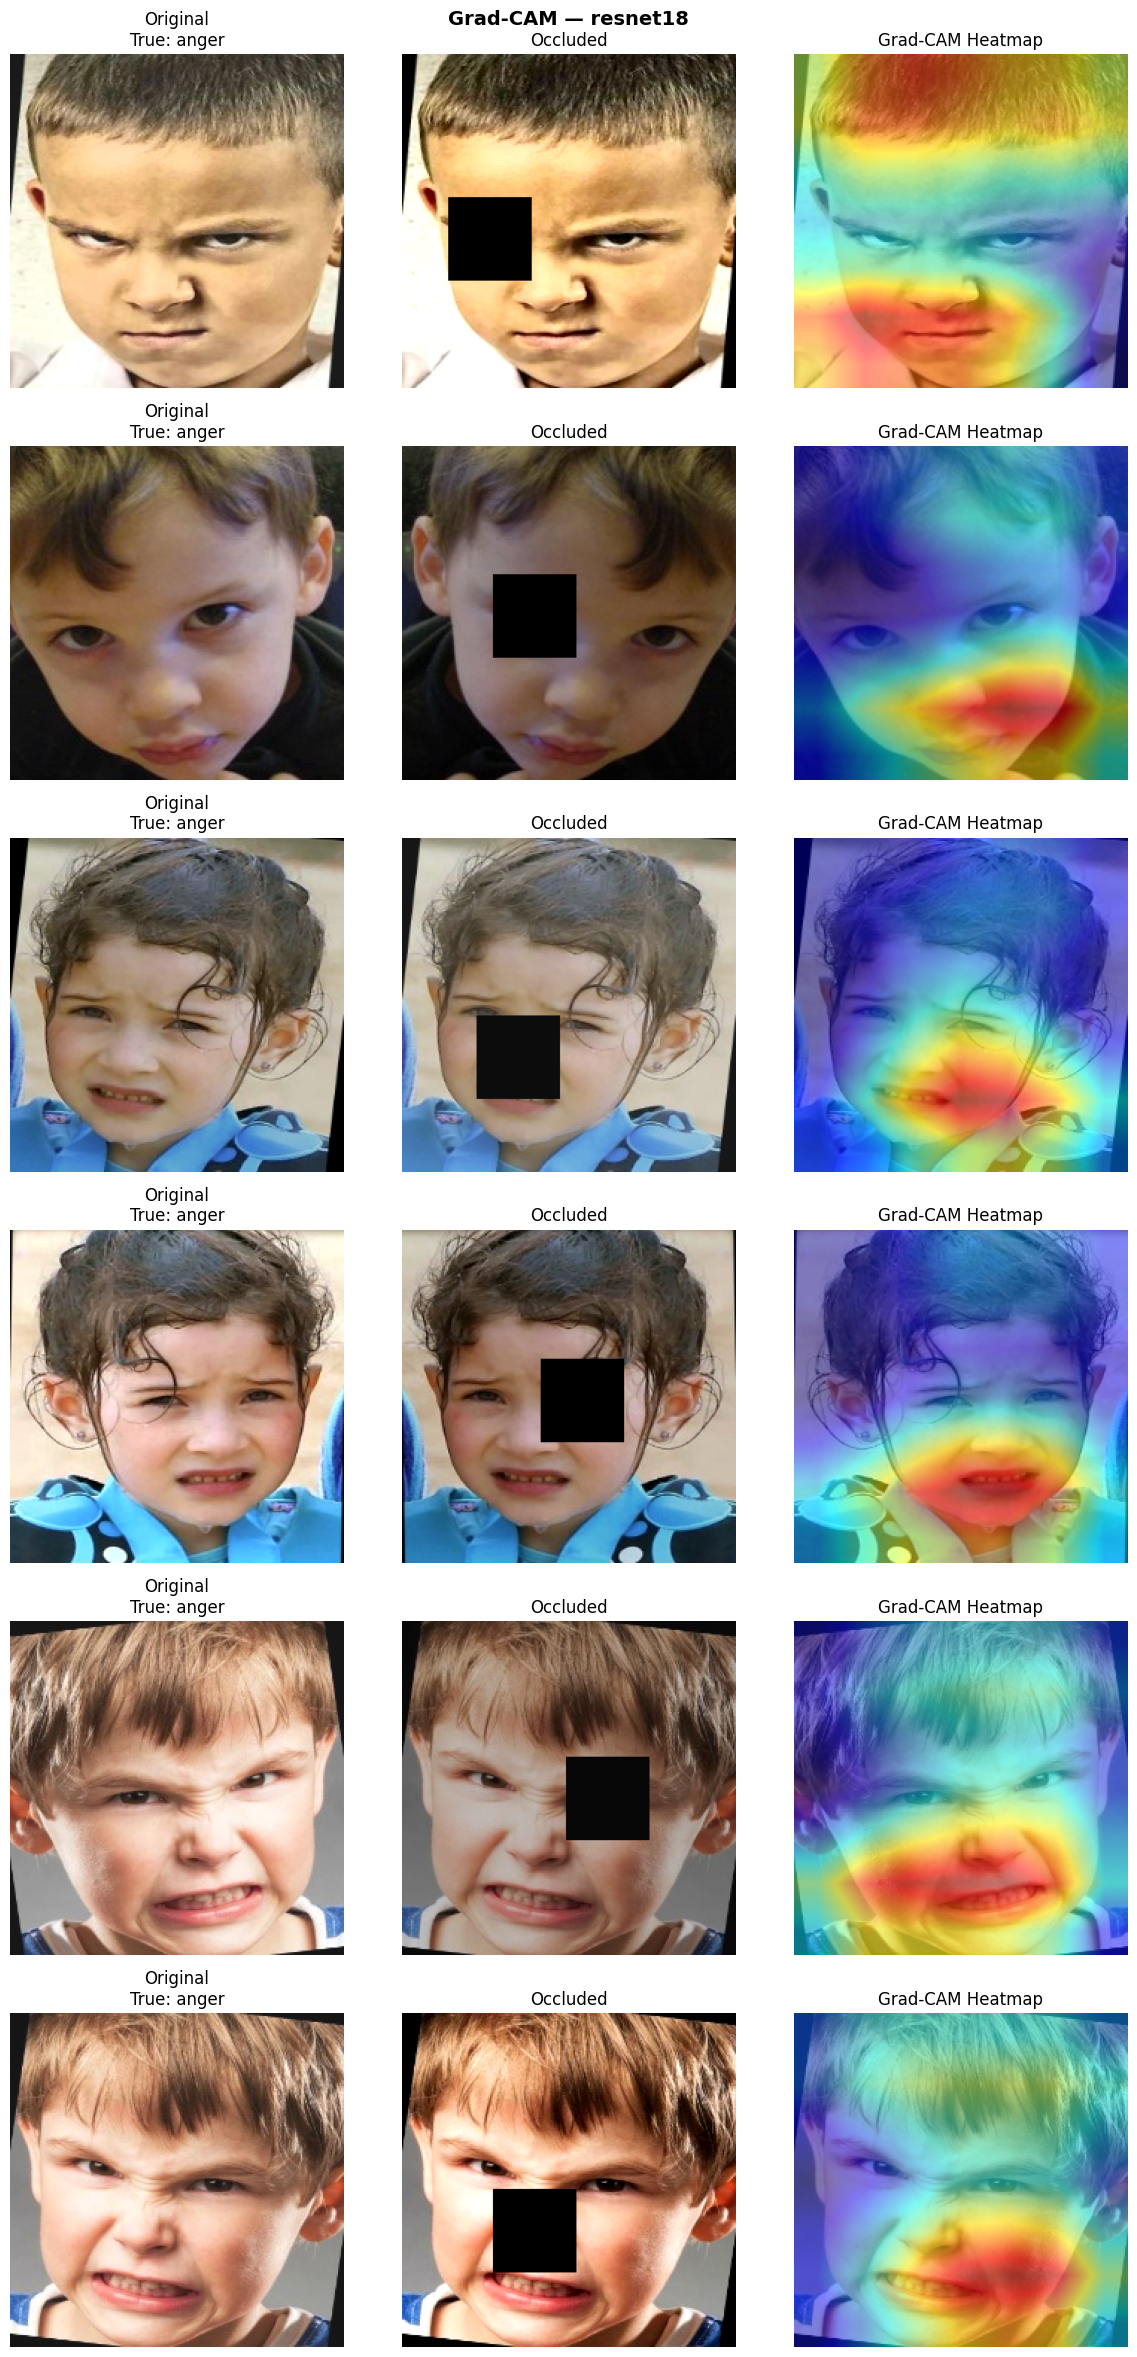

Grad-CAM saved for resnet18


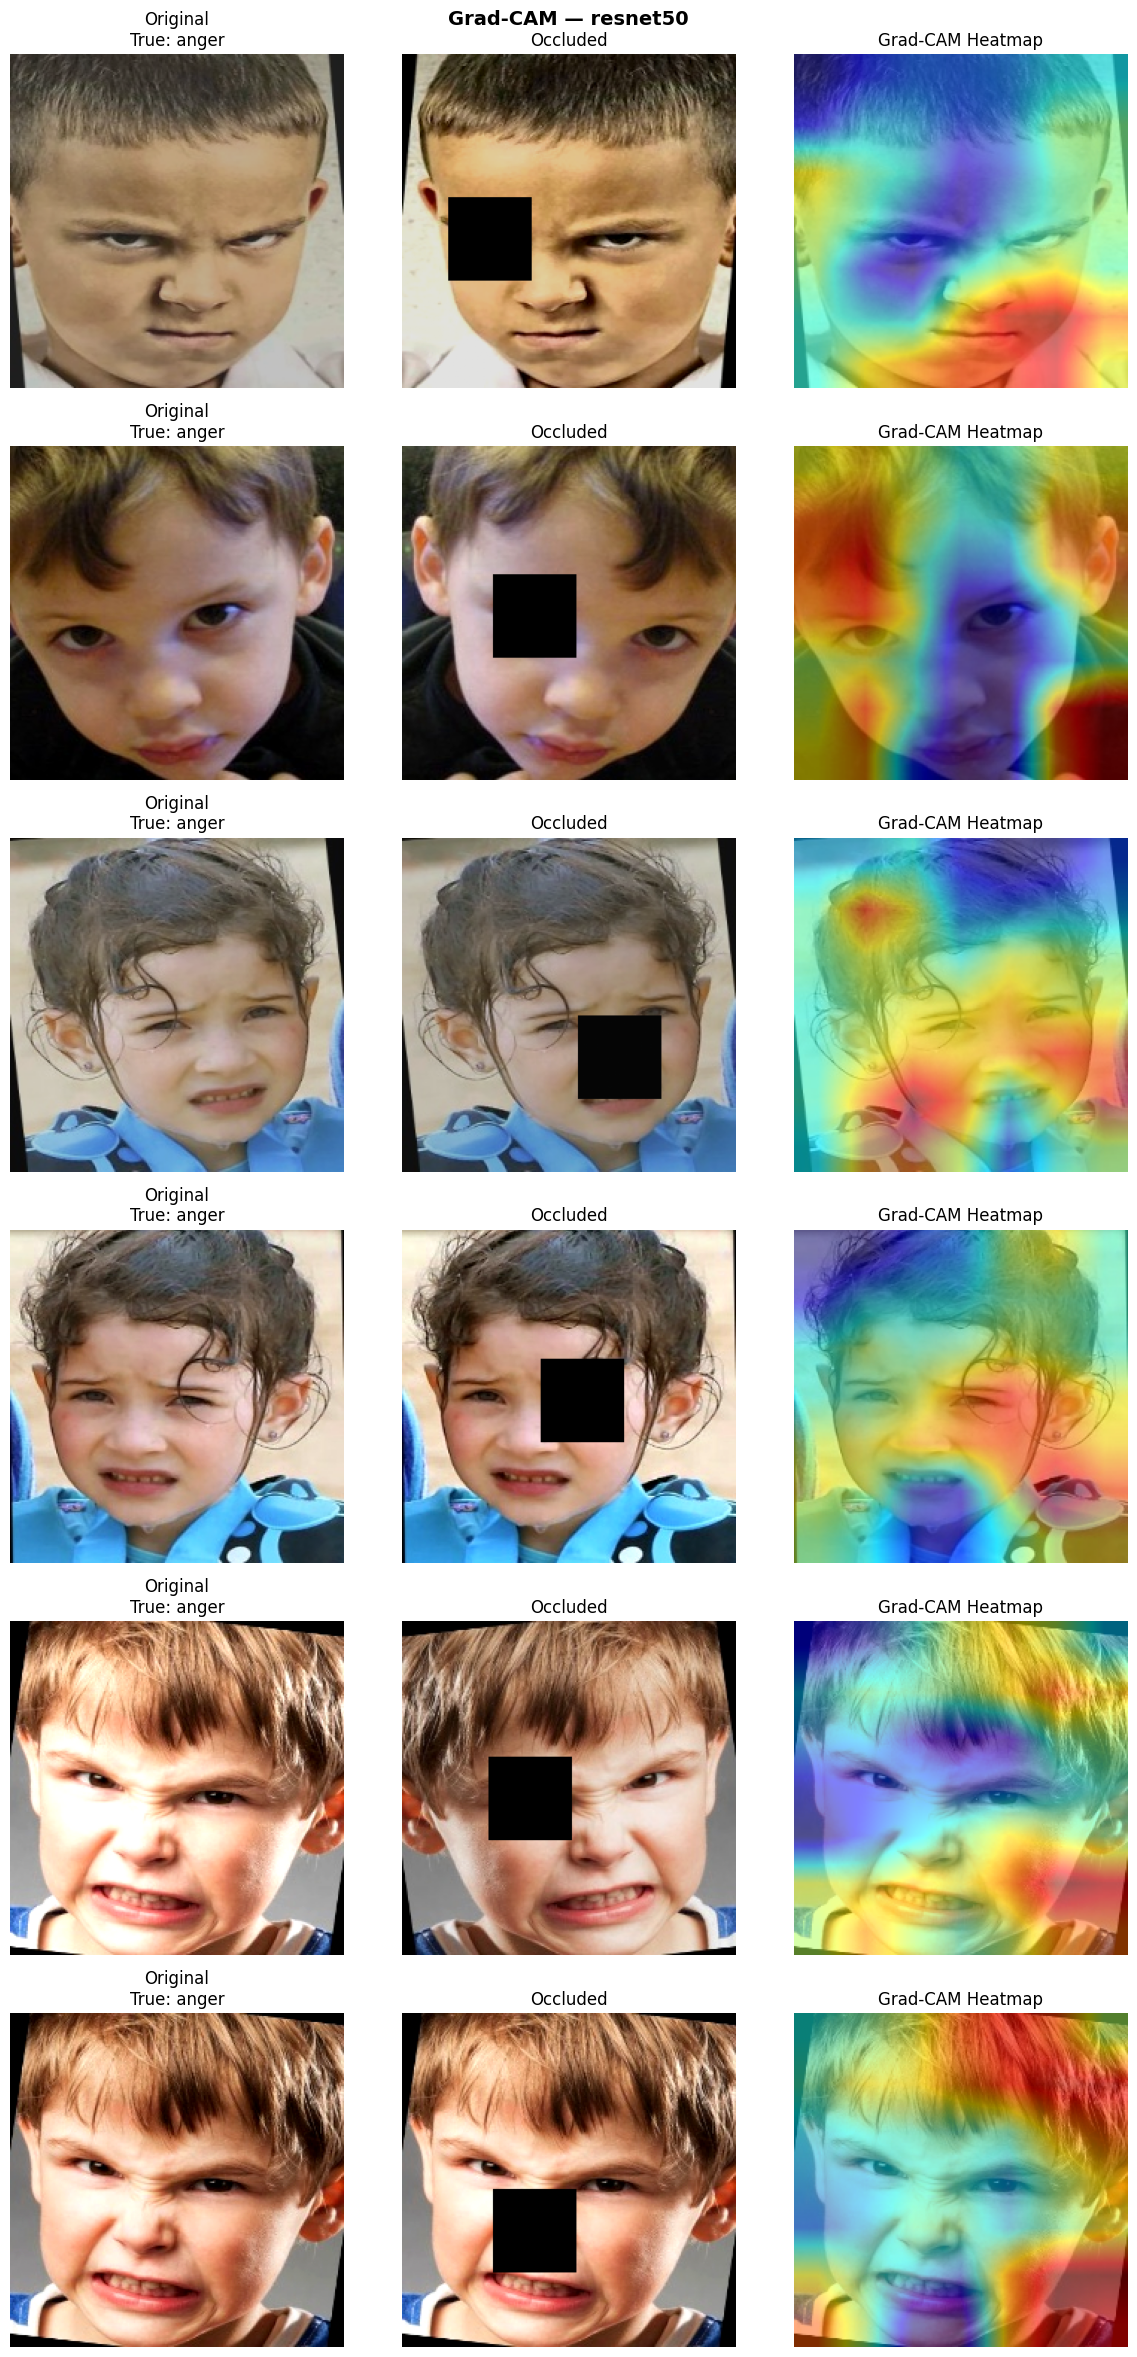

Grad-CAM saved for resnet50


ValueError: Invalid grads shape.Shape of grads should be 4 (2D image) or 5 (3D image).

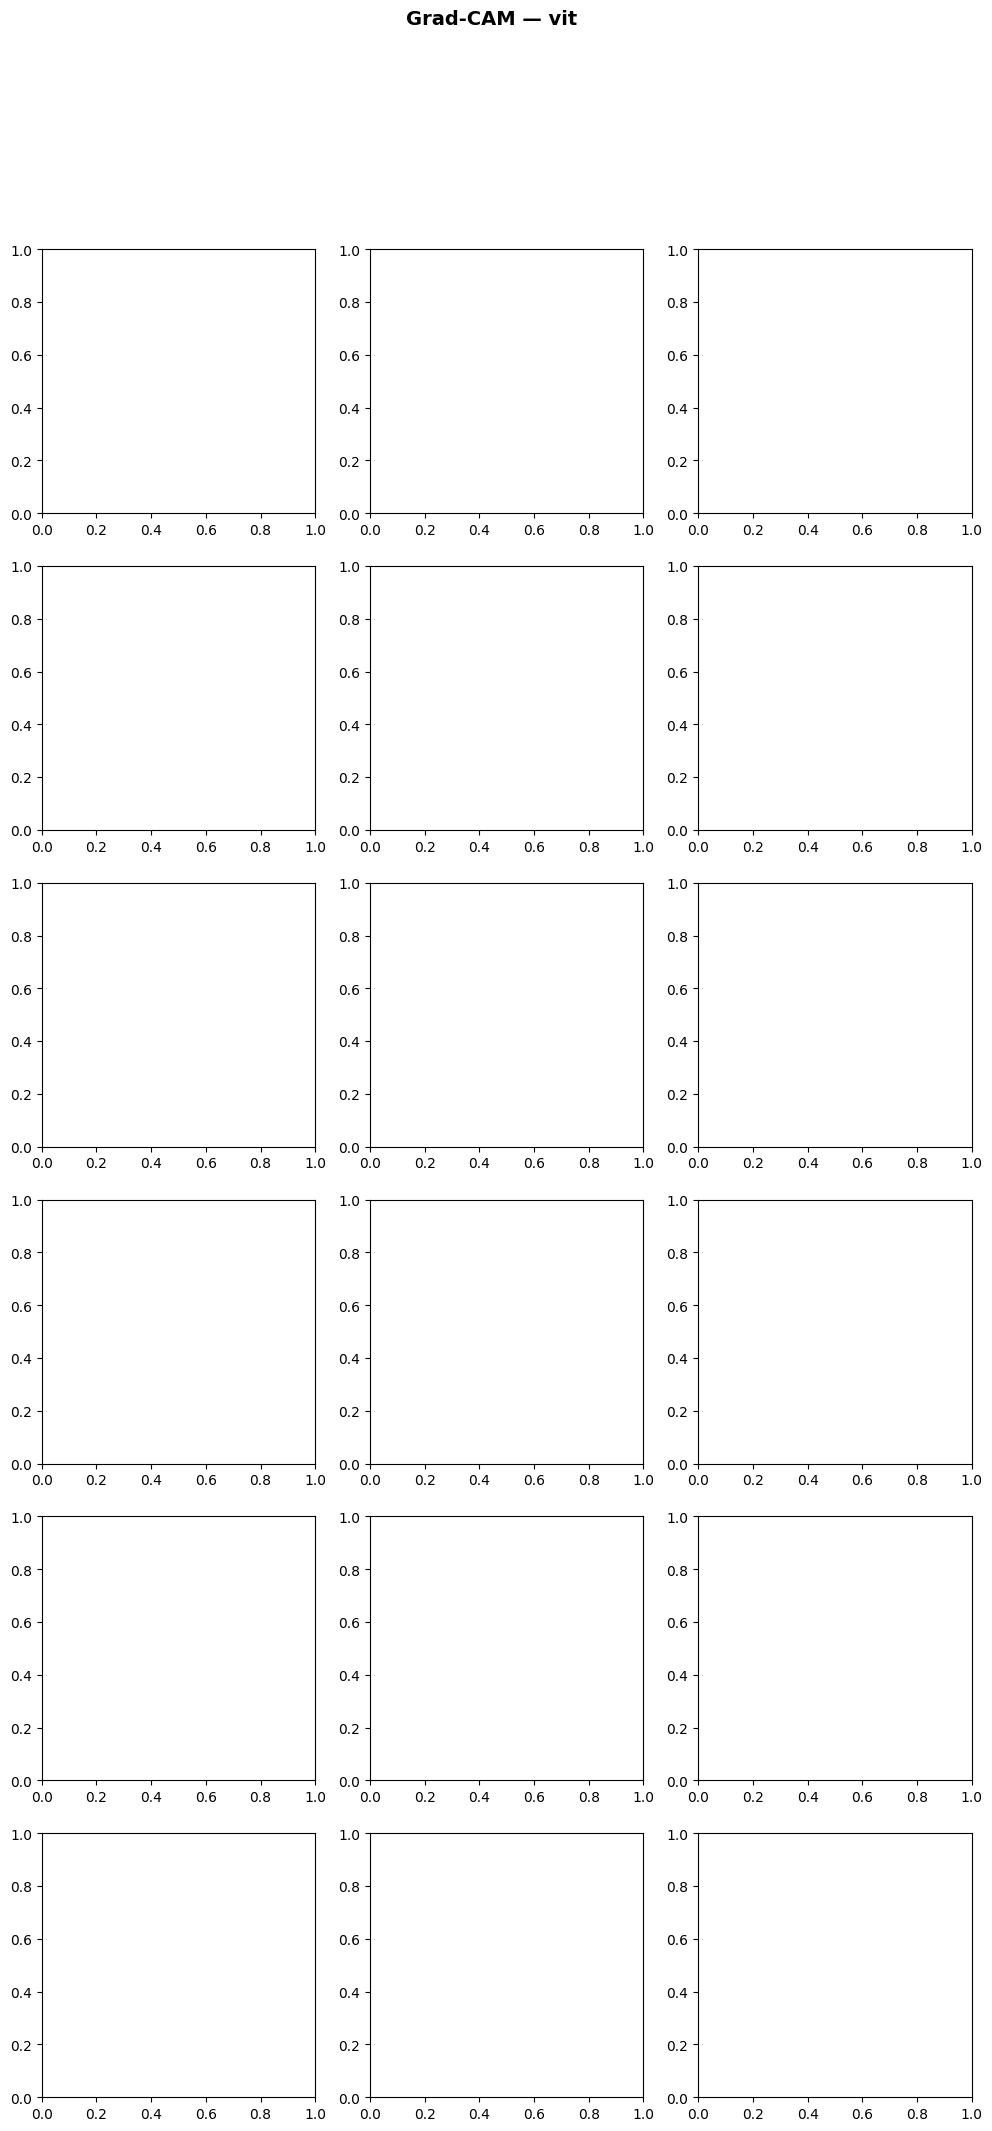

In [20]:
## Grad-CAM Visualization

def apply_gradcam(model, model_name, dataset, num_samples=6):
    """Generate Grad-CAM visualizations for sample images."""

    # Select target layer based on model type
    if 'resnet' in model_name:
        target_layers = [model.layer4[-1]]
    elif model_name == 'multiscale_vit':
        target_layers = [model.backbone.blocks[-1].norm1]
    else:  # vit
        target_layers = [model.blocks[-1].norm1]


    cam = GradCAM(model=model, target_layers=target_layers)

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    fig.suptitle(f'Grad-CAM — {model_name}', fontsize=14, fontweight='bold')

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i in range(num_samples):
        stacked, label = dataset[i]
        input_tensor = stacked.unsqueeze(0).to(DEVICE)

        # Original image (first 3 channels)
        original_img = (stacked[:3] * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()

        # Occluded image (last 3 channels)
        occluded_img = (stacked[3:] * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()

        # Generate CAM
        targets = [ClassifierOutputTarget(label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        cam_image = show_cam_on_image(original_img.astype(np.float32), grayscale_cam, use_rgb=True)

        # Plot
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f'Original\nTrue: {IDX_CLASS[label]}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(occluded_img)
        axes[i, 1].set_title('Occluded')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(cam_image)
        axes[i, 2].set_title('Grad-CAM Heatmap')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{model_name}_gradcam.png'), dpi=150)
    plt.show()
    print(f'Grad-CAM saved for {model_name}')


# Run Grad-CAM on ALL 4 models
apply_gradcam(model_resnet18,  'resnet18',       full_train)
apply_gradcam(model_resnet50,  'resnet50',       full_train)
apply_gradcam(model_vit,       'vit',            full_train)
apply_gradcam(model_ms_vit,    'multiscale_vit', full_train)

In [21]:
model_files = {
    'resnet18'   : os.path.join(MODELS_DIR, 'resnet18_best.pth'),
    'resnet50'   : os.path.join(MODELS_DIR, 'resnet50_best.pth'),
    'vit'        : os.path.join(MODELS_DIR, 'vit_best.pth'),
    'multiscale_vit': os.path.join(MODELS_DIR, 'multiscale_vit_best.pth'),
}

# Copy best model weights to fer_best.pth
best_src  = model_files[best_fer_model_name]
best_dest = os.path.join(MODELS_DIR, 'fer_best.pth')
shutil.copy(best_src, best_dest)

# Save config JSON — the fusion notebook reads this
fer_config = {
    'best_model'   : best_fer_model_name,
    'best_test_acc': float(results[best_fer_model_name]),
    'num_classes'  : NUM_CLASSES,
    'emotions'     : EMOTIONS,
    'class_map'    : CLASS_MAP,
    'input_channels': 6,
    'input_size'   : 224,
    'all_results'  : {k: float(v) for k, v in results.items()},
    'normalisation': {
        'mean': [0.485, 0.456, 0.406],
        'std' : [0.229, 0.224, 0.225]
    }
}

config_path = os.path.join(MODELS_DIR, 'fer_model_config.json')
with open(config_path, 'w') as f:
    json.dump(fer_config, f, indent=2)

print(f' Best FER model : {best_fer_model_name}  ({results[best_fer_model_name]:.4f})')
print(f' Weights saved  : {best_dest}')
print(f'Config saved   : {config_path}')
print(f'\nAll models in: {MODELS_DIR}')
for f in sorted(os.listdir(MODELS_DIR)):
    print(f'  {f}')

 Best FER model : resnet18  (0.6239)
 Weights saved  : Autism emotion recognition dataset/models/fer_best.pth
Config saved   : Autism emotion recognition dataset/models/fer_model_config.json

All models in: Autism emotion recognition dataset/models
  fer_best.pth
  fer_model_config.json
  multiscale_vit_best.pth
  resnet18_best.pth
  resnet50_best.pth
  vit_best.pth


In [22]:
def format_fer_output(logits, emotions):
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    emotion_scores = [
        {
            "label": emotions[i].capitalize(),
            "value": round(float(probs[i] * 100), 2)
        }
        for i in range(len(probs))
    ]

    top_idx = int(np.argmax(probs))

    result = {
        "top_emotion": emotions[top_idx].capitalize(),
        "confidence": round(float(probs[top_idx] * 100), 2),
        "emotions": emotion_scores
    }

    return result